In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import scipy.stats as st
from sklearn.feature_selection import mutual_info_regression

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv("C:\\Users\\vb100\\OneDrive\\LPNU\\8_семестр_(4)\\БКР\\dyploma project\\model_dyploma\\scout_data.csv", encoding='utf-8')
df.head()

,scout id,category,age,interests,event id,name,description,type,start date,end date,price,currency,min age,max age,is online,rating
0,s1001,лідер,24,"управління, виживання, медицина",e5001,Тренінг «Основи Скаутингу»,Даний захід спрямований на формування розумінн...,тренінг,2026-04-18,2026-04-19,200.0,UAH,18,60,False,3
1,s1002,ровер,19,"картографія, спортивне орієнтування, природа",e5002,Тренінг з проєктного менеджменту,Опанування дорослими лідерами та роверами мето...,тренінг,2026-10-18,2026-10-19,250.0,UAH,18,22,False,4
2,s1003,скаут,14,"кемпінг, плавання, вузли",e5003,JOTA-JOTI 2026,Найбільша онлайн-подія Всесвітнього Скаутингу ...,конференція,2026-10-17,2026-10-19,0.0,UAH,6,60,True,4
3,s1004,ровер,20,"управління, дослідження, природа",e5004,Форум Роверів «Вектор дії»,Тренінг спрямований допомогти роверам обрати с...,тренінг,2026-12-11,2026-12-15,0.0,UAH,16,24,False,4
4,s1005,ровер,22,"управління, картографія, природа",e5005,Міжнародний Скаутський Форум у Кувейті,Участь у міжнародній події для представлення у...,конференція,2026-01-11,2026-01-25,1000.0,USD,18,26,False,3


In [3]:
interest_counts = df['interests'].str.split(', ').explode().value_counts()
interest_counts

interests
природа                   617
дослідження               487
виживання                 419
управління                408
вузли                     379
медицина                  347
картографія               220
кемпінг                   209
скелелазіння              198
кулінарія                 187
плавання                  172
стрільба з лука           130
спортивне орієнтування     63
веломандрівки              51
полювання                  34
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scout id     1307 non-null   str    
 1   category     1307 non-null   str    
 2   age          1307 non-null   int64  
 3   interests    1307 non-null   str    
 4   event id     1307 non-null   str    
 5   name         1307 non-null   str    
 6   description  1307 non-null   str    
 7   type         1307 non-null   str    
 8   start date   1307 non-null   str    
 9   end date     1307 non-null   str    
 10  price        1307 non-null   float64
 11  currency     1307 non-null   str    
 12  min age      1307 non-null   int64  
 13  max age      1307 non-null   int64  
 14  is online    1307 non-null   bool   
 15  rating       1307 non-null   int64  
dtypes: bool(1), float64(1), int64(4), str(10)
memory usage: 154.6 KB


In [5]:
df['start date'] = pd.to_datetime(df['start date'])
df['end date'] = pd.to_datetime(df['end date'])
print(df['start date'].dtype)
print(df['end date'].dtype)

datetime64[us]
datetime64[us]


In [6]:
print(df.duplicated().sum())
print(df.isna().sum().sum())
print(df.isnull().sum().sum())

2
0
0


In [7]:
df[df.duplicated()]

,scout id,category,age,interests,event id,name,description,type,start date,end date,price,currency,min age,max age,is online,rating
652,s1540,кабскаут,8,"кулінарія, природа, дослідження",e5312,Квест «Мапа лісовика»,Одноденний пригодницький офлайн-квест для кабс...,естафета,2026-05-10,2026-05-10,350.0,UAH,6,11,False,2
660,s1401,кабскаут,9,"кулінарія, природа, вузли",e5312,Квест «Мапа лісовика»,Одноденний пригодницький офлайн-квест для кабс...,естафета,2026-05-10,2026-05-10,350.0,UAH,6,11,False,1


In [8]:
ids_to_check = ['s1540', 's1401']
df[df['scout id'].isin(ids_to_check) & df.duplicated(keep=False)].sort_values(by='scout id')

,scout id,category,age,interests,event id,name,description,type,start date,end date,price,currency,min age,max age,is online,rating
362,s1401,кабскаут,9,"кулінарія, природа, вузли",e5312,Квест «Мапа лісовика»,Одноденний пригодницький офлайн-квест для кабс...,естафета,2026-05-10,2026-05-10,350.0,UAH,6,11,False,1
660,s1401,кабскаут,9,"кулінарія, природа, вузли",e5312,Квест «Мапа лісовика»,Одноденний пригодницький офлайн-квест для кабс...,естафета,2026-05-10,2026-05-10,350.0,UAH,6,11,False,1
600,s1540,кабскаут,8,"кулінарія, природа, дослідження",e5312,Квест «Мапа лісовика»,Одноденний пригодницький офлайн-квест для кабс...,естафета,2026-05-10,2026-05-10,350.0,UAH,6,11,False,2
652,s1540,кабскаут,8,"кулінарія, природа, дослідження",e5312,Квест «Мапа лісовика»,Одноденний пригодницький офлайн-квест для кабс...,естафета,2026-05-10,2026-05-10,350.0,UAH,6,11,False,2


In [9]:
df.drop_duplicates(inplace=True)

In [11]:
df['interests'].unique()

<StringArray>
[             'управління, виживання, медицина',
 'картографія, спортивне орієнтування, природа',
                     'кемпінг, плавання, вузли',
             'управління, дослідження, природа',
             'управління, картографія, природа',
             'медицина, дослідження, виживання',
           'скелелазіння, природа, дослідження',
           'управління, дослідження, кулінарія',
                 'кемпінг, плавання, виживання',
       'вузли, кемпінг, спортивне орієнтування',
 ...
                    'виживання, кемпінг, вузли',
            'медицина, дослідження, управління',
             'виживання, скелелазіння, природа',
                     'вузли, природа, плавання',
           'управління, картографія, виживання',
          'стрільба з лука, виживання, природа',
          'стрільба з лука, природа, виживання',
                 'плавання, вузли, дослідження',
           'виживання, управління, дослідження',
                   'плавання, вузли, виживання']
L

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 1305 entries, 0 to 1306
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   scout id     1305 non-null   str           
 1   category     1305 non-null   str           
 2   age          1305 non-null   int64         
 3   interests    1305 non-null   str           
 4   event id     1305 non-null   str           
 5   name         1305 non-null   str           
 6   description  1305 non-null   str           
 7   type         1305 non-null   str           
 8   start date   1305 non-null   datetime64[us]
 9   end date     1305 non-null   datetime64[us]
 10  price        1305 non-null   float64       
 11  currency     1305 non-null   str           
 12  min age      1305 non-null   int64         
 13  max age      1305 non-null   int64         
 14  is online    1305 non-null   bool          
 15  rating       1305 non-null   int64         
dtypes: bool(1), datetime64

### functions

In [12]:
def vis_target_balance(input_df: pd.DataFrame):
  columns = input_df.columns
  n_cols = len(columns)
  n_rows = math.ceil(n_cols / 2)
  fig, axs = plt.subplots(n_rows, 2, figsize = (14,6*n_rows))
  if n_cols == 1 and n_rows == 1:
     if not isinstance(axs, np.ndarray):
        all_axs = [axs]
     else:
        all_axs = axs.flatten()
  else:
     all_axs = axs.flatten()
   
  for i, col in enumerate(columns):
    counts = input_df[col].value_counts().sort_index()
    sns.barplot(x = counts.index, y=counts.values, ax=all_axs[i], color = 'firebrick')
    all_axs[i].set(title = f"% of '{col}' classes")
    total = len(input_df[col])
    if len(counts) > 5:
            all_axs[i].tick_params(axis='x', rotation=30)
    for j, val in enumerate(counts.values):
        percentage = (val / total) * 100
        y_offset = max(counts.values) * 0.02
        all_axs[i].text(j, val + y_offset, f'{percentage:.1f}% ({val})', ha='center')

  for k in range(i + 1, len(all_axs)):
        all_axs[k].axis('off')

  plt.tight_layout()
  plt.show()

In [13]:
def describe_numerical(df: pd.DataFrame):
    desc_df = df.describe()
    desc_df.loc['skewness'] = df.skew()
    desc_df.loc['kurtosis'] = df.kurt()
    return desc_df

In [14]:
def cols_histplots(df, nrows=2, ncols=3, figsize=(14,8)):
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs=axs.flatten()
    for i, col in enumerate(df):
        mean=df[col].mean()
        std=df[col].std()

        sns.histplot(x=df[col], ax=axs[i], kde=True)
        axs[i].set_title(f'Distribution of {col}')

        col_legend=f'Mean: {mean:.4f}\nStd: {std:.4f}'
        axs[i].legend([col_legend], loc='best', frameon=True)

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

In [15]:
def cols_boxplots(df, nrows=2, ncols=3, figsize=(14,8)):
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs=axs.flatten()
    for i, col in enumerate(df):
        sns.boxplot(x=df[col], ax=axs[i], showfliers=True)
        axs[i].set_title(f'Distribution of {col}')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

In [16]:
def log_to_norm_histplot(df, nrows=1, ncols=1, figsize=(7,5)):
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs=np.array(axs).flatten()
    for i, col in enumerate(df):
        norm_col = np.log1p(df[col])
        sns.histplot(x=norm_col, ax=axs[i], kde=True)
        axs[i].set_title(f'Normalized distribution of {col}')
        mean=norm_col.mean()
        std=norm_col.std()
        col_legend=f'Mean: {mean:.4f}\nStd: {std:.4f}'
        axs[i].legend([col_legend], loc='best', frameon=True)

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

In [17]:
def vis_cat_balance(input_df: pd.DataFrame):
  columns = input_df.columns
  n_cols = len(columns)
  n_rows = math.ceil(n_cols / 2)
  fig, axs = plt.subplots(n_rows, 2, figsize = (14,5.5*n_rows))
  if n_cols == 1 and n_rows == 1:
     if not isinstance(axs, np.ndarray):
        all_axs = [axs]
     else:
        all_axs = axs.flatten()
  else:
     all_axs = axs.flatten()
   
  for i, col in enumerate(columns):
    counts = input_df[col].value_counts().sort_index()
    sns.barplot(x = counts.index, y=counts.values, ax=all_axs[i], color = 'firebrick')
    all_axs[i].set(title = f"% of '{col}' classes")
    total = len(input_df[col])
    if len(counts) > 5:
            all_axs[i].tick_params(axis='x', rotation=30)
    for j, val in enumerate(counts.values):
        percentage = (val / total) * 100
        y_offset = max(counts.values) * 0.02
        all_axs[i].text(j, val + y_offset, f'{percentage:.1f}% ({val})', ha='center')

  for k in range(i + 1, len(all_axs)):
        all_axs[k].axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
def vis_mi_corr(mi_df: pd.DataFrame, correlation_df: pd.DataFrame):
    fig, axs = plt.subplots(1, 2, figsize=(14,7), sharey='row')
    sns.barplot(x=mi_df.index, y=mi_df['MI score'], palette='plasma', ax=axs[0])
    axs[0].set(title ='MI score between num cols and rating', 
            xlabel='Numerical columns')

    sns.barplot(x=correlation_df.index, y=correlation_df.values, palette='plasma', ax=axs[1])
    axs[1].set(title ='Correlation between num cols and rating', 
            xlabel='Numerical columns')

    for ax in axs:
        for p in ax.patches:
            val = p.get_height()
            offset = 0.001 if val >= 0 else -0.007
            
            ax.text(
                p.get_x() + p.get_width() / 2., 
                val + offset,                  
                f'{val:.3f}',                   
                ha='center', 
                fontsize=11, 
            )

    plt.tight_layout()
    plt.show()

In [20]:
def vis_cat_target(df: pd.DataFrame, cat_columns: list[str], target_column: str, nrows=3, ncols=2, figsize=(12, 11)):
    fig, axs=plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axs=np.array(axs).flatten()

    for i, cat_col in enumerate(cat_columns):
        crosstab = pd.crosstab(df[cat_col], df[target_column])
        chi2_stat, p_value, _, _= st.chi2_contingency(crosstab)

        crosstab.plot(kind='bar', ax=axs[i], colormap='Spectral', stacked=True)
        axs[i].set_title(f'{cat_col} dependence on {target_column}\n (chi2_stat: {chi2_stat:.2f}, p-value: {p_value:.20f})')
        axs[i].tick_params(axis='x', rotation=45)

        for idx, row in enumerate(crosstab.values):
            total = row.sum()
            bottom = 0
            for j, value in enumerate(row):
                percent = value / total * 100
                axs[i].annotate(f'{percent:.1f}%', xy=(idx, bottom + value / 2), ha='center', va='center', fontsize=10, color='black')
                bottom += value

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

In [ ]:
def chi_test(col1: pd.Series, col2: pd.Series):
    cont_table = pd.crosstab(col1, col2)
    chi2_stat, p_value, _, _ = st.chi2_contingency(cont_table)
    print(f"Chi-square statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print(f"Fail to reject H0: there is no statistically significant relationship between '{col1.name}' and '{col2.name}'")
    else:
        print(f"Reject H0: there is a statistically significant relationship between '{col1.name}' and '{col2.name}'")

    n = len(col1)

    v = np.sqrt(chi2_stat / (n * (min(cont_table.shape) - 1)))
    print(f"Cramer's V = {v:.2f}")

### primary EDA

In [26]:
df.head()

,scout id,category,age,interests,event id,name,description,type,start date,end date,price,currency,min age,max age,is online,rating
0,s1001,лідер,24,"управління, виживання, медицина",e5001,Тренінг «Основи Скаутингу»,Даний захід спрямований на формування розумінн...,тренінг,2026-04-18,2026-04-19,200.0,UAH,18,60,False,3
1,s1002,ровер,19,"картографія, спортивне орієнтування, природа",e5002,Тренінг з проєктного менеджменту,Опанування дорослими лідерами та роверами мето...,тренінг,2026-10-18,2026-10-19,250.0,UAH,18,22,False,4
2,s1003,скаут,14,"кемпінг, плавання, вузли",e5003,JOTA-JOTI 2026,Найбільша онлайн-подія Всесвітнього Скаутингу ...,конференція,2026-10-17,2026-10-19,0.0,UAH,6,60,True,4
3,s1004,ровер,20,"управління, дослідження, природа",e5004,Форум Роверів «Вектор дії»,Тренінг спрямований допомогти роверам обрати с...,тренінг,2026-12-11,2026-12-15,0.0,UAH,16,24,False,4
4,s1005,ровер,22,"управління, картографія, природа",e5005,Міжнародний Скаутський Форум у Кувейті,Участь у міжнародній події для представлення у...,конференція,2026-01-11,2026-01-25,1000.0,USD,18,26,False,3


In [27]:
df['duration'] = df['end date'] - df['start date']

In [28]:
df['duration']

0       1 days
1       1 days
2       2 days
3       4 days
4      14 days
         ...  
1302    9 days
1303    0 days
1304    0 days
1305    7 days
1306    0 days
Name: duration, Length: 1305, dtype: timedelta64[us]

In [29]:
df['duration'] = df['duration'].dt.days

In [30]:
df['duration'] = df['duration'] +1

In [31]:
df['duration'].value_counts().sort_index()

duration
1     302
2     168
3     191
4      83
5     154
6      45
7      49
8      60
9      12
10     80
11    124
15     13
24     24
Name: count, dtype: int64

In [32]:
df['season'] = (df['start date'].dt.month % 12) // 3

In [33]:
df['season']

0       1
1       3
2       3
3       0
4       0
       ..
1302    2
1303    1
1304    1
1305    2
1306    1
Name: season, Length: 1305, dtype: int32

In [34]:
df.drop(columns=['start date', 'end date'], inplace = True)

In [35]:
df['rating'].describe()

count    1305.000000
mean        3.231418
std         1.097303
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: rating, dtype: float64

In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 1305 entries, 0 to 1306
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scout id     1305 non-null   str    
 1   category     1305 non-null   str    
 2   age          1305 non-null   int64  
 3   interests    1305 non-null   str    
 4   event id     1305 non-null   str    
 5   name         1305 non-null   str    
 6   description  1305 non-null   str    
 7   type         1305 non-null   str    
 8   price        1305 non-null   float64
 9   currency     1305 non-null   str    
 10  min age      1305 non-null   int64  
 11  max age      1305 non-null   int64  
 12  is online    1305 non-null   bool   
 13  rating       1305 non-null   int64  
 14  duration     1305 non-null   int64  
 15  season       1305 non-null   int32  
dtypes: bool(1), float64(1), int32(1), int64(5), str(8)
memory usage: 159.3 KB


#### numerical

In [37]:
numeric_data = df.select_dtypes(include = ('number')).drop(columns=['rating', 'season'])

In [38]:
describe_numerical(numeric_data)

,age,price,min age,max age,duration
count,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000
mean,18.316475,842.205364,13.363218,31.631418,4.941762
std,7.772765,1141.109410,4.468691,18.777306,4.342292
min,7.000000,0.000000,6.000000,9.000000,1.000000
25%,14.000000,110.000000,11.000000,17.000000,2.000000
50%,16.000000,350.000000,14.000000,24.000000,3.000000
75%,21.000000,1100.000000,18.000000,55.000000,7.000000
max,54.000000,5000.000000,25.000000,65.000000,24.000000
skewness,1.223857,1.828614,-0.330996,0.626984,1.839032
kurtosis,1.750976,2.510843,-0.980440,-1.293788,4.829558


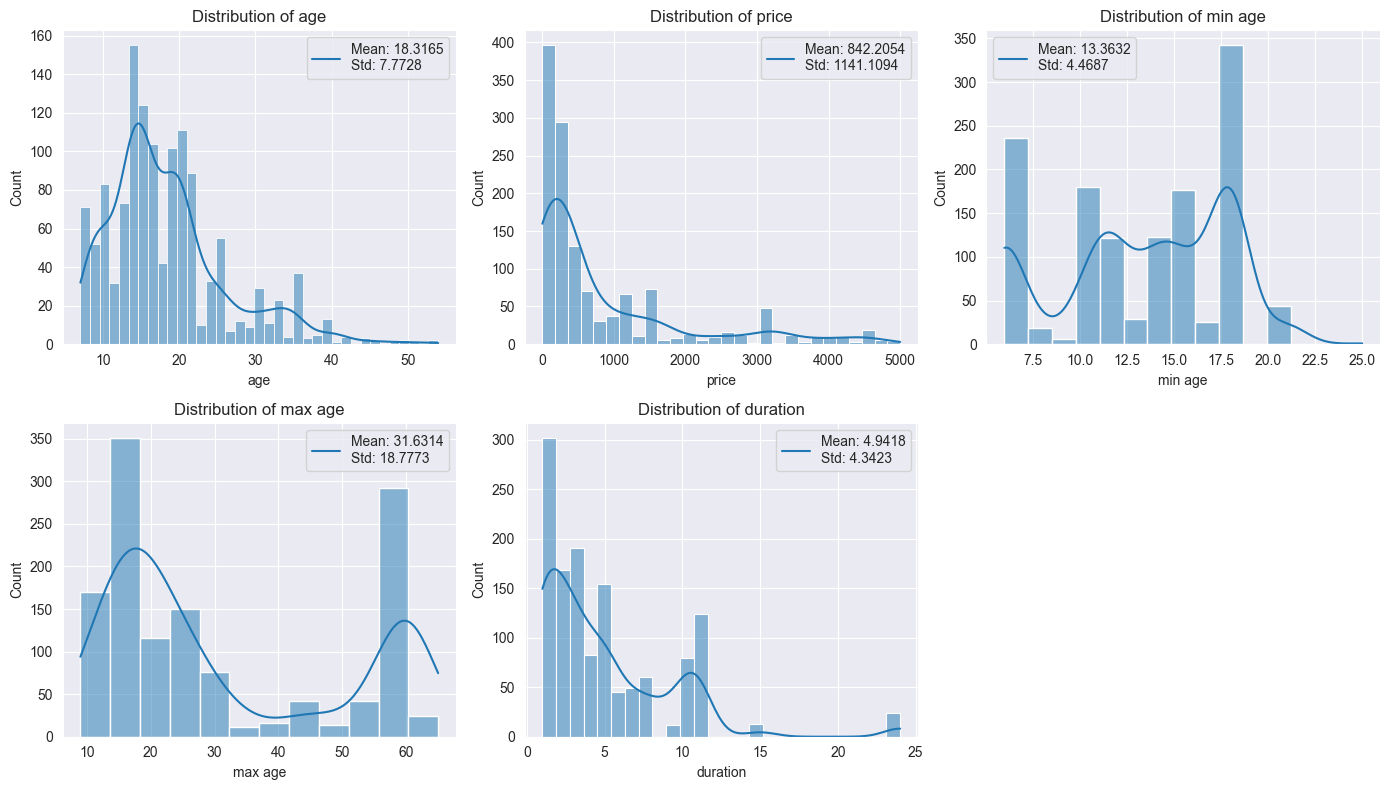

In [39]:
cols_histplots(numeric_data)

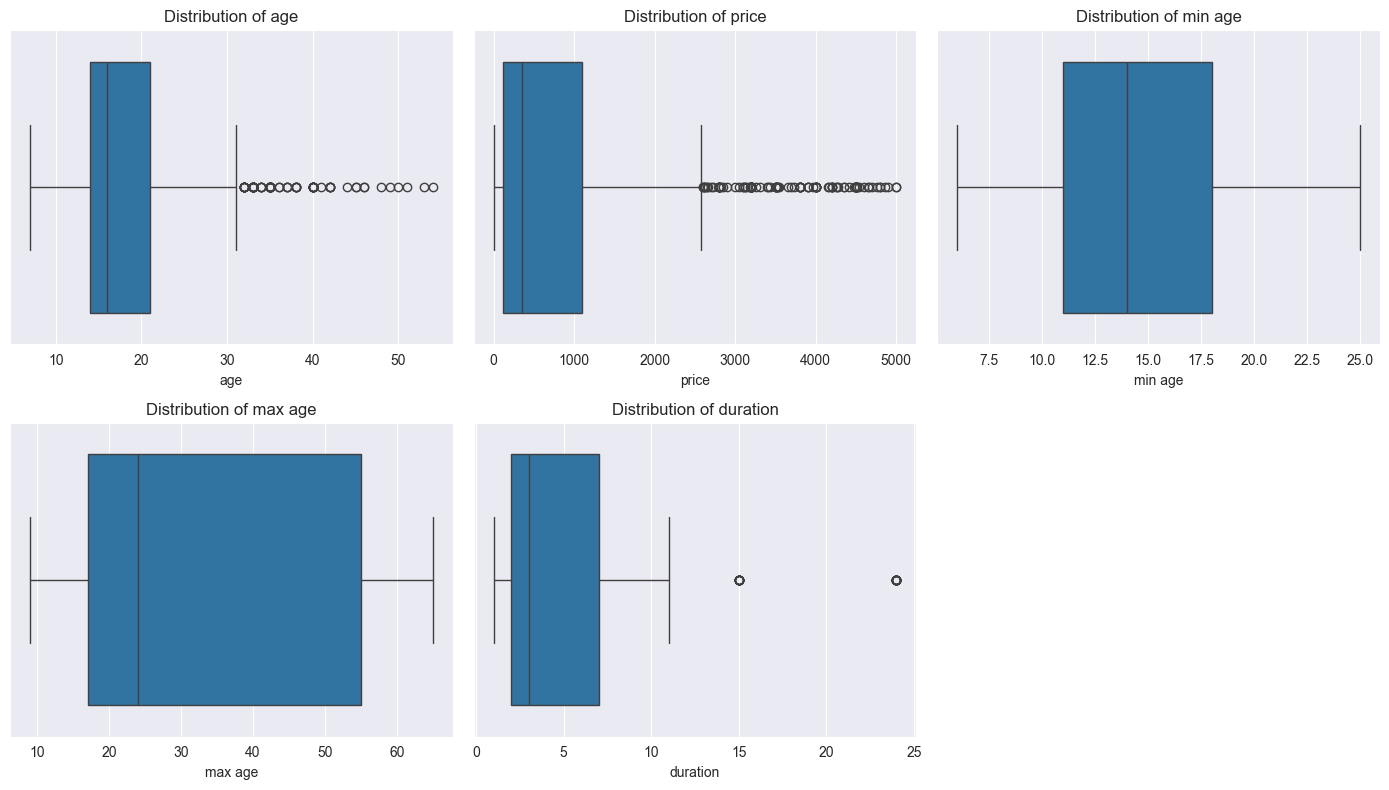

In [40]:
cols_boxplots(numeric_data)

##### target

In [41]:
describe_numerical(df[['rating']])

,rating
count,1305.000000
mean,3.231418
std,1.097303
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000
skewness,-0.125696
kurtosis,-0.704980


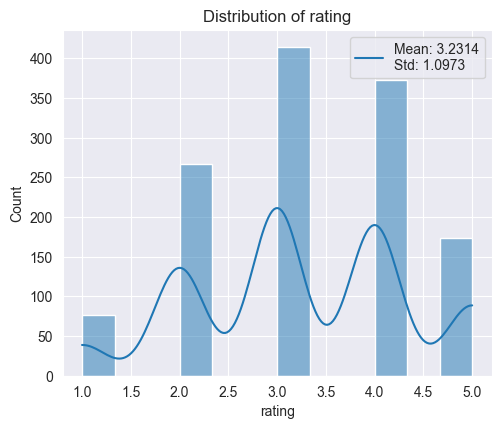

In [42]:
cols_histplots(df[['rating']])

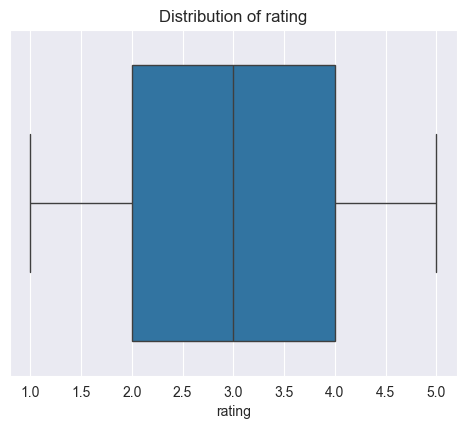

In [43]:
cols_boxplots(df[['rating']])

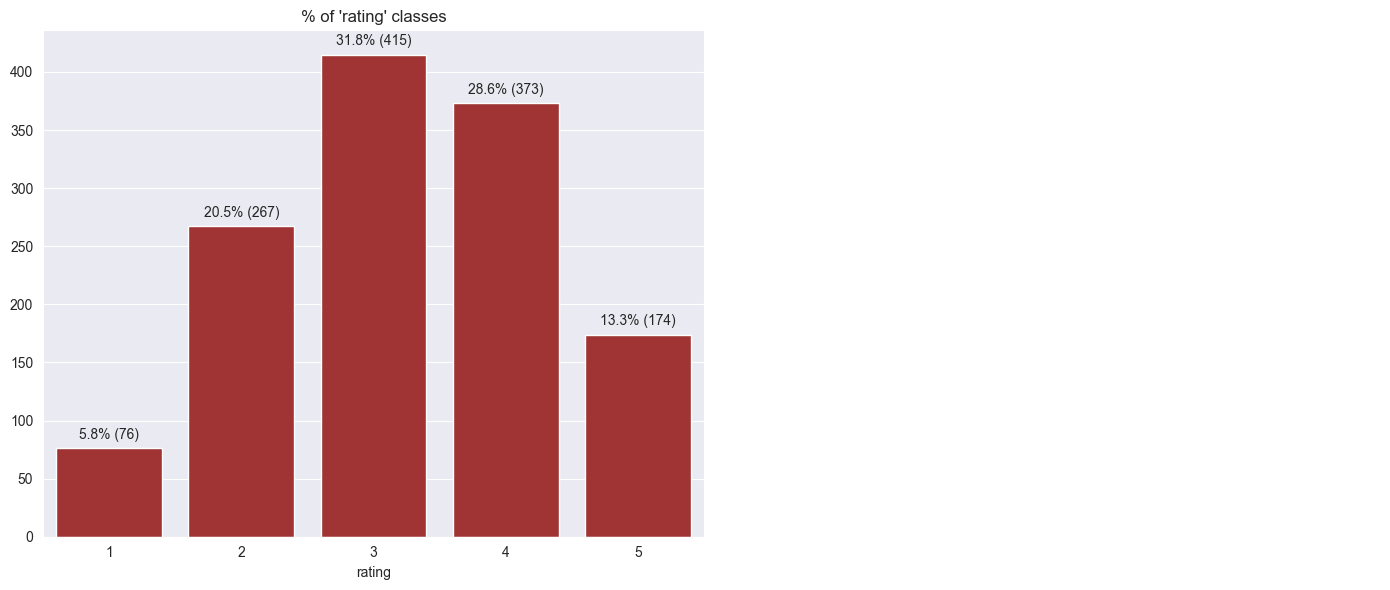

In [44]:
vis_target_balance(df[['rating']])

Висновок: всі фічі препроцесяться через StandardScaler(), а `price` додатково через log(), оскільки є дуже довгий хвіст

##### log()

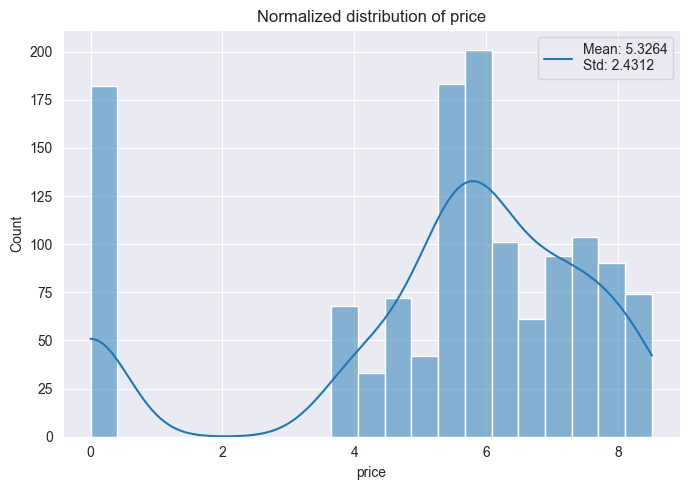

In [45]:
log_to_norm_histplot(df[['price']])

In [46]:
skewness_after = np.log1p(df['price']).skew()
print(f'Skewness of price after normalization: {skewness_after}')

Skewness of price after normalization: -1.1913868055972954


#### categorical

In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 1305 entries, 0 to 1306
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scout id     1305 non-null   str    
 1   category     1305 non-null   str    
 2   age          1305 non-null   int64  
 3   interests    1305 non-null   str    
 4   event id     1305 non-null   str    
 5   name         1305 non-null   str    
 6   description  1305 non-null   str    
 7   type         1305 non-null   str    
 8   price        1305 non-null   float64
 9   currency     1305 non-null   str    
 10  min age      1305 non-null   int64  
 11  max age      1305 non-null   int64  
 12  is online    1305 non-null   bool   
 13  rating       1305 non-null   int64  
 14  duration     1305 non-null   int64  
 15  season       1305 non-null   int32  
dtypes: bool(1), float64(1), int32(1), int64(5), str(8)
memory usage: 159.3 KB


In [48]:
df.columns

Index(['scout id', 'category', 'age', 'interests', 'event id', 'name',
       'description', 'type', 'price', 'currency', 'min age', 'max age',
       'is online', 'rating', 'duration', 'season'],
      dtype='str')

In [49]:
categorical = df[['category', 'type', 'currency', 'is online', 'season']].copy()
categorical = categorical.astype({col: 'category' for col in categorical.select_dtypes(include=['string', 'number']).columns})
categorical.info()

<class 'pandas.DataFrame'>
Index: 1305 entries, 0 to 1306
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   category   1305 non-null   category
 1   type       1305 non-null   category
 2   currency   1305 non-null   category
 3   is online  1305 non-null   bool    
 4   season     1305 non-null   category
dtypes: bool(1), category(4)
memory usage: 16.7 KB


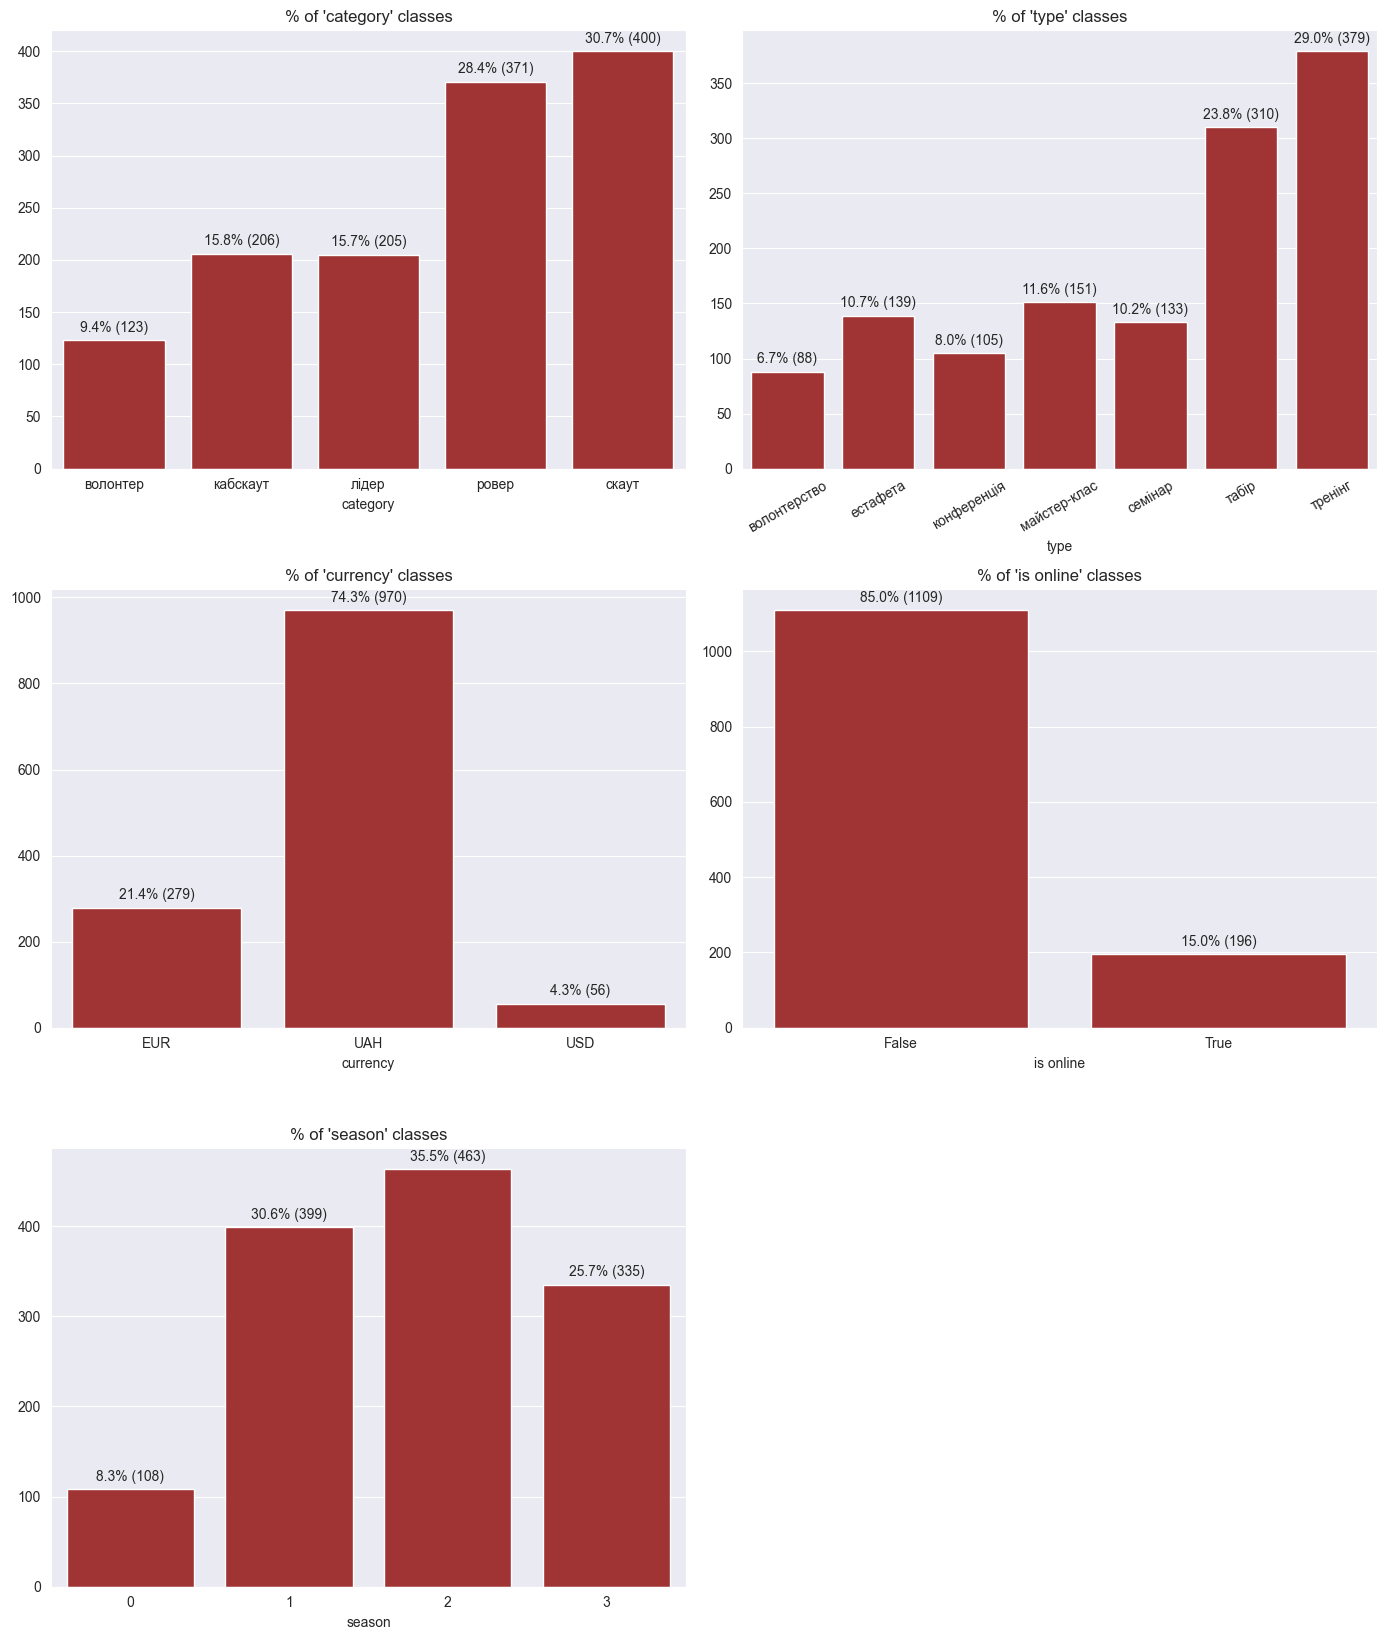

In [51]:
vis_cat_balance(categorical)

### bivariate/multivariate EDA

In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 1305 entries, 0 to 1306
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scout id     1305 non-null   str    
 1   category     1305 non-null   str    
 2   age          1305 non-null   int64  
 3   interests    1305 non-null   str    
 4   event id     1305 non-null   str    
 5   name         1305 non-null   str    
 6   description  1305 non-null   str    
 7   type         1305 non-null   str    
 8   price        1305 non-null   float64
 9   currency     1305 non-null   str    
 10  min age      1305 non-null   int64  
 11  max age      1305 non-null   int64  
 12  is online    1305 non-null   bool   
 13  rating       1305 non-null   int64  
 14  duration     1305 non-null   int64  
 15  season       1305 non-null   int32  
dtypes: bool(1), float64(1), int32(1), int64(5), str(8)
memory usage: 159.3 KB


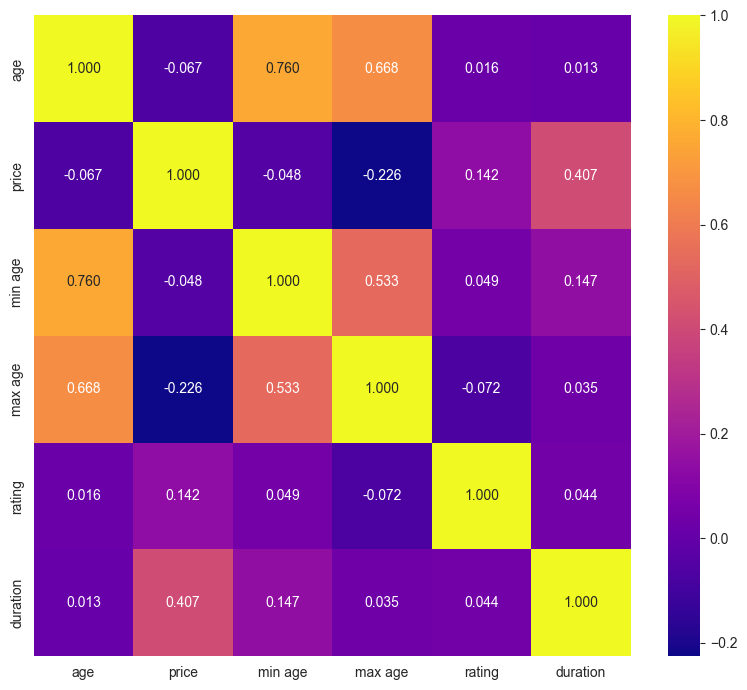

In [53]:
corr_df = df.select_dtypes(include='number').drop(columns='season')
corr_matrix = corr_df.corr()
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr_matrix, fmt=".3f", annot=True, cmap='plasma', ax=ax)
plt.tight_layout()
plt.show()

In [54]:
mutual_info = mutual_info_regression(X=numeric_data, y=df['rating'])
mutual_info_df = pd.DataFrame(mutual_info, index=numeric_data.columns, columns=['MI score'])
mutual_info_df

,MI score
age,0.076271
price,0.133602
min age,0.010322
max age,0.077943
duration,0.037848


In [55]:
mutual_info_df = mutual_info_df.sort_values(by='MI score', ascending=False)

corr_without_rating = corr_matrix['rating'].drop('rating').reindex(mutual_info_df.index)

C:\Users\vb100\AppData\Local\Temp\ipykernel_40200\2862719341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_df.index, y=mi_df['MI score'], palette='plasma', ax=axs[0])
C:\Users\vb100\AppData\Local\Temp\ipykernel_40200\2862719341.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_df.index, y=correlation_df.values, palette='plasma', ax=axs[1])


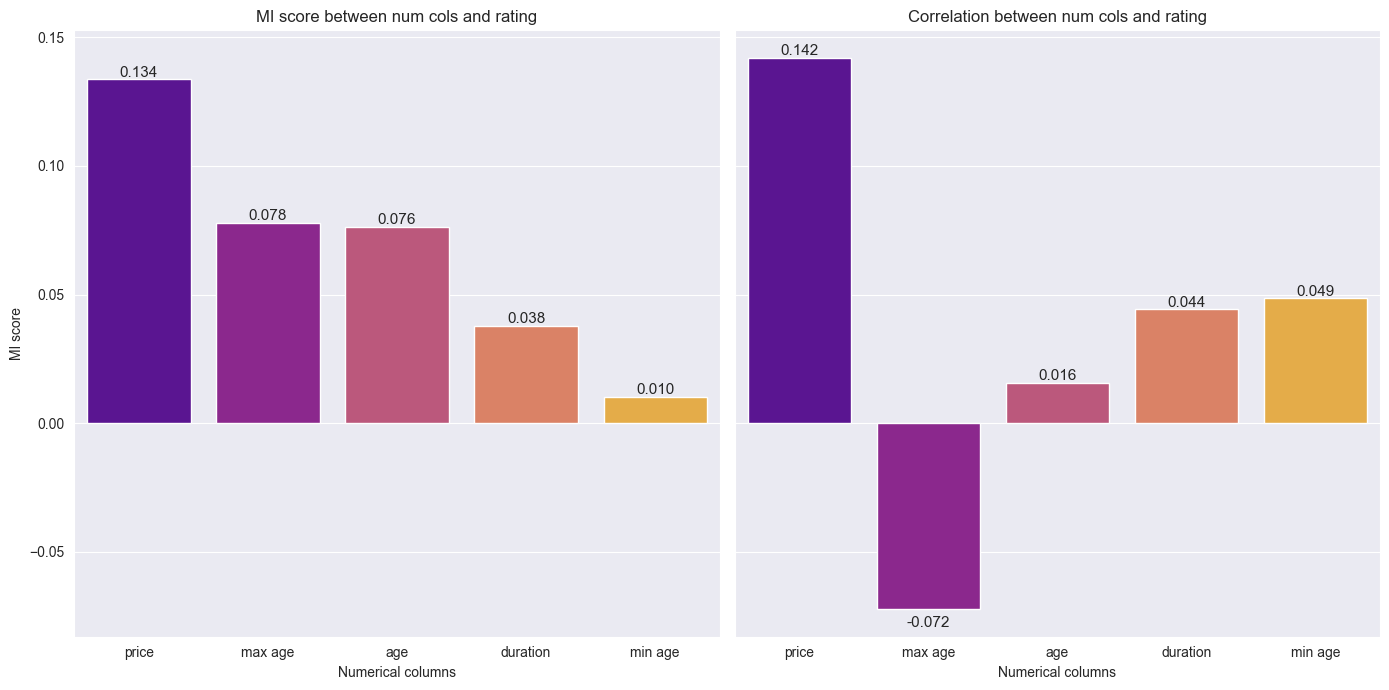

In [56]:
vis_mi_corr(mutual_info_df, corr_without_rating)

In [57]:
categorical.info()

<class 'pandas.DataFrame'>
Index: 1305 entries, 0 to 1306
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   category   1305 non-null   category
 1   type       1305 non-null   category
 2   currency   1305 non-null   category
 3   is online  1305 non-null   bool    
 4   season     1305 non-null   category
dtypes: bool(1), category(4)
memory usage: 16.7 KB


In [60]:
cat_names = ['category', 'type', 'currency', 'is online', 'season']

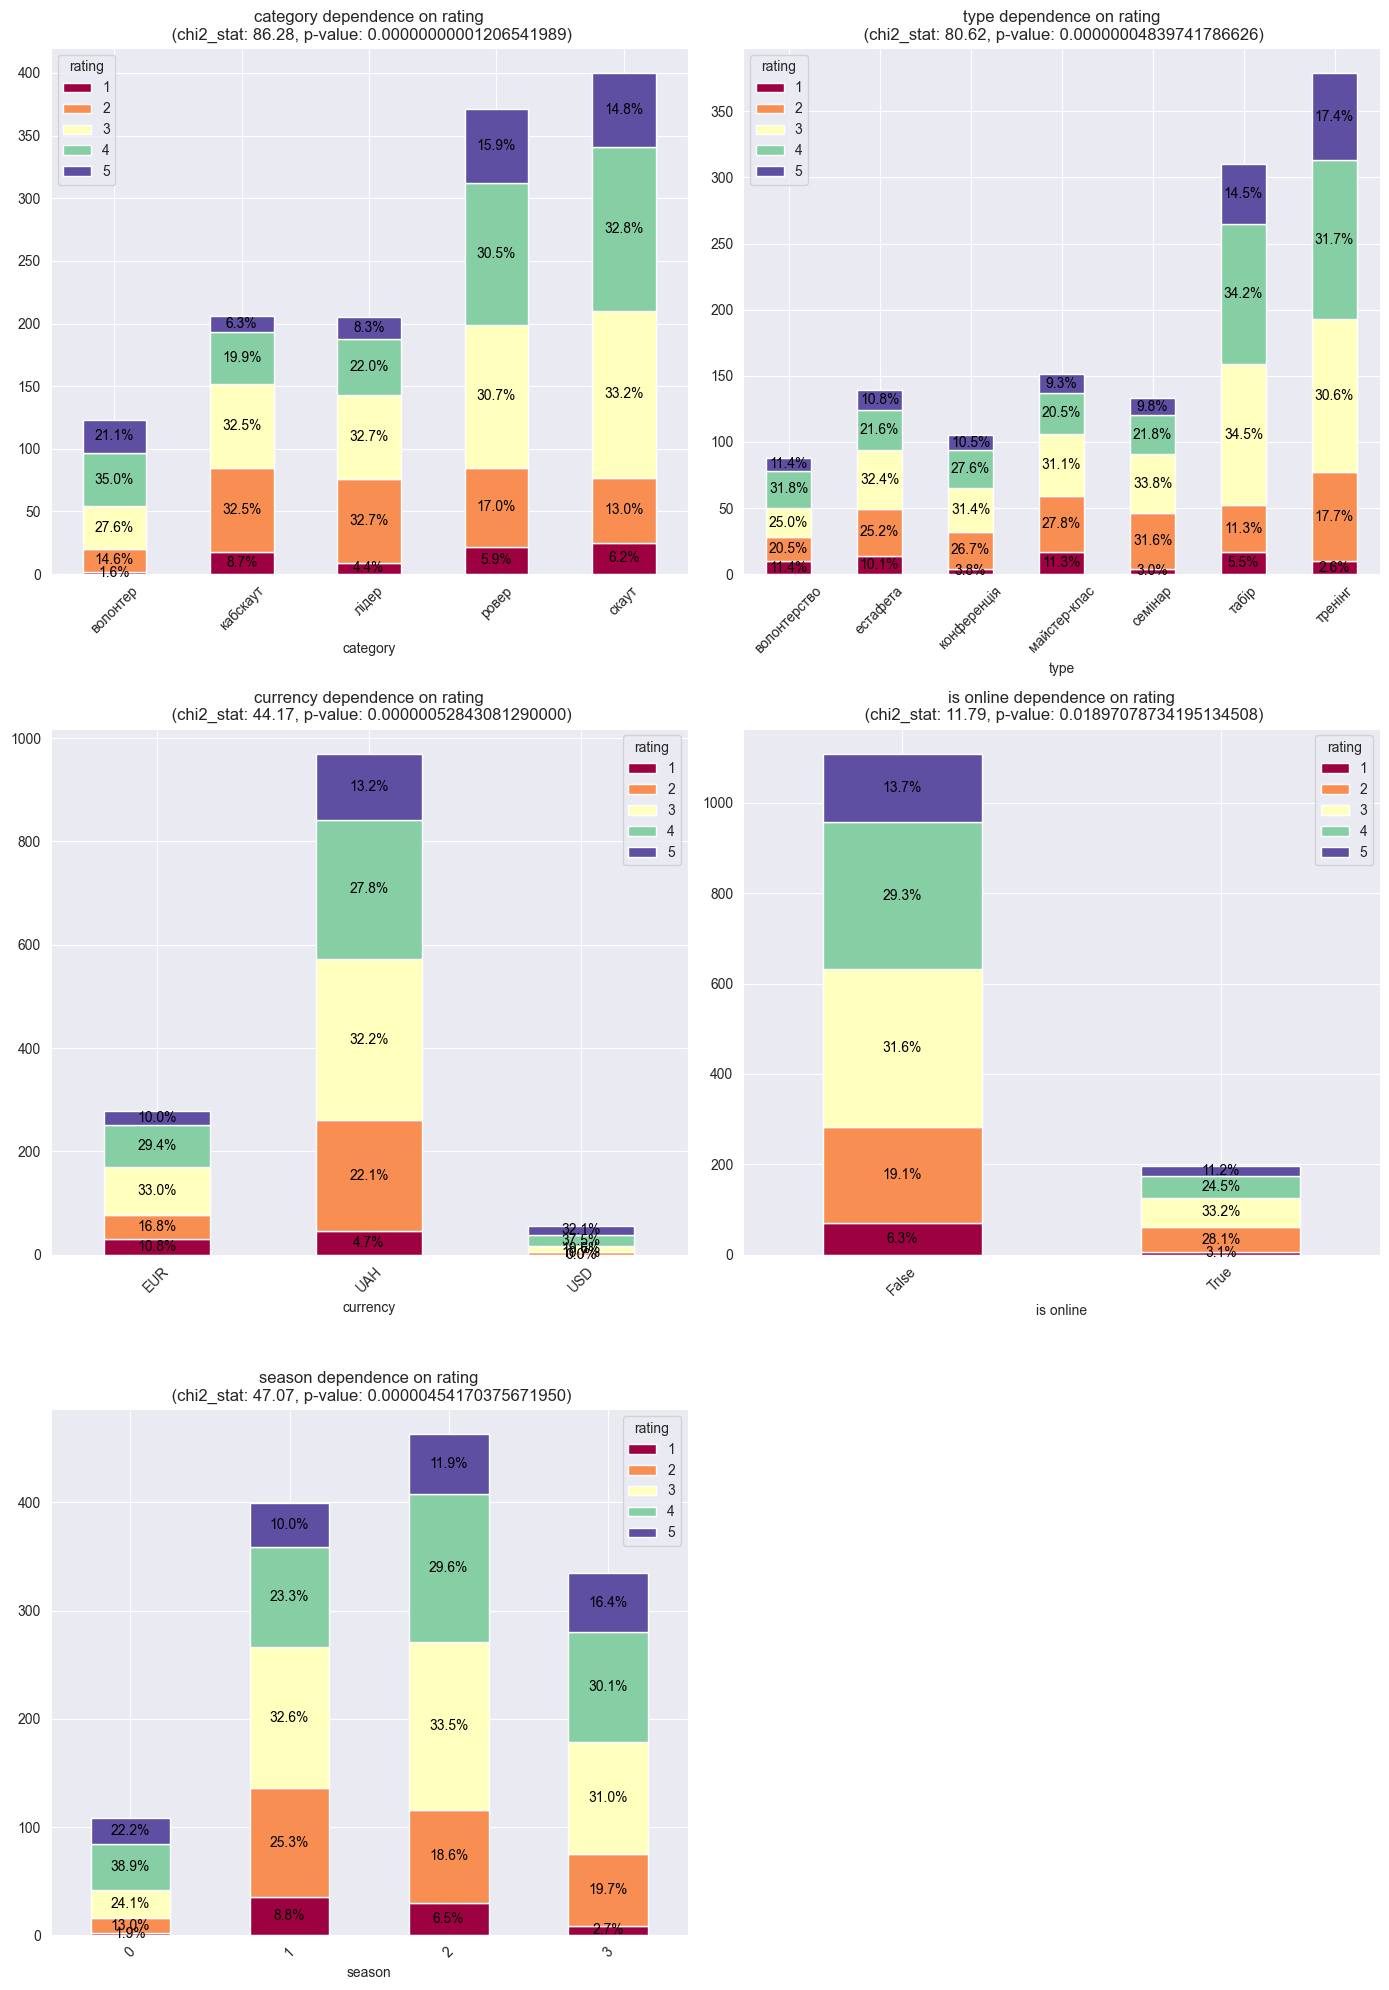

In [61]:
vis_cat_target(df, cat_names, 'rating', figsize=(14, 20))

In [64]:
chi_test(df['category'], df['type'])
print('\n')
chi_test(df['category'], df['currency'])
print('\n')
chi_test(df['category'], df['is online'])
print('\n')
chi_test(df['category'], df['season'])
print('\n')
chi_test(df['type'], df['currency'])
print('\n')
chi_test(df['type'], df['is online'])
print('\n')
chi_test(df['type'], df['season'])
print('\n')
chi_test(df['currency'], df['is online'])
print('\n')
chi_test(df['currency'], df['season'])
print('\n')
chi_test(df['is online'], df['season'])

Chi-square statistic: 926.2793
P-value: 0.0000
Reject H0: there is a statistically significant relationship between 'category' and 'type'
Cramer's V = 0.42


Chi-square statistic: 122.1448
P-value: 0.0000
Reject H0: there is a statistically significant relationship between 'category' and 'currency'
Cramer's V = 0.22


Chi-square statistic: 151.7333
P-value: 0.0000
Reject H0: there is a statistically significant relationship between 'category' and 'is online'
Cramer's V = 0.34


Chi-square statistic: 368.2117
P-value: 0.0000
Reject H0: there is a statistically significant relationship between 'category' and 'season'
Cramer's V = 0.31


Chi-square statistic: 404.6399
P-value: 0.0000
Reject H0: there is a statistically significant relationship between 'type' and 'currency'
Cramer's V = 0.39


Chi-square statistic: 637.6056
P-value: 0.0000
Reject H0: there is a statistically significant relationship between 'type' and 'is online'
Cramer's V = 0.70


Chi-square statistic: 720.8749
P-value: 

In [65]:
cont_table = pd.crosstab(df['category'], df['type'])

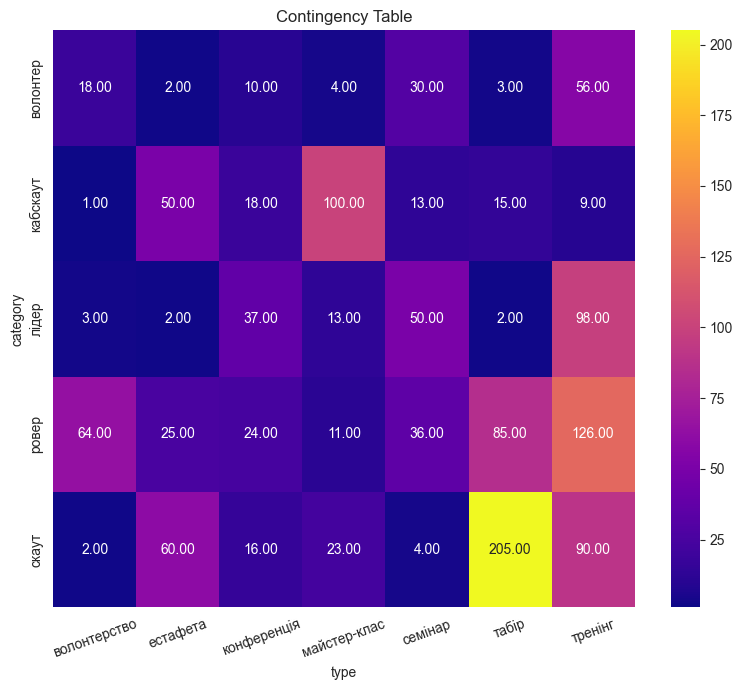

In [66]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cont_table, fmt = '.2f', annot=True, cmap='plasma', cbar=True, ax=ax)
ax.set_title('Contingency Table')
ax.tick_params(axis = 'x', rotation = 20)
plt.tight_layout()
plt.show()